<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/statprak3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Serial test

Idea: break the sequence $x_1, x_2, x_3, ..., x_{2n}$ into consecutive series of length $2$: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ and look at each element as a random and independent point in $2D$ space. Next, apply chi-square. Similarly, one can construct series of length $3, 4$, etc.

### Problem 1
Implement serial test and apply to a `samples`

In [2]:
import numpy as np
from scipy.stats import chisquare

def serial_test_2d_scipy(sequence, d=10):
    n_points = len(sequence) // 2
    points = sequence.reshape(-1, 2)
    observed, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=d, range=[[0, 1], [0, 1]])
    observed_flat = observed.flatten()
    expected_value = n_points / (d**2)
    statistic, p_value = chisquare(f_obs=observed_flat, f_exp=expected_value)
    return statistic, p_value

seq = np.random.rand(2000)
stat, p = serial_test_2d_scipy(seq, d=5)

print(f"Статистика: {stat:.4f}")
print(f"P-value: {p:.4f}")

Статистика: 20.5000
P-value: 0.6680


### Permutation test

We again decompose the sequence $x_1, x_2, x_3, ..., x_{dn}$ into consecutive series of length $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. A series of $d$ elements can be ordered in $d!$ ways and each way of ordering is equally probable. Hence the idea of the test is to count how many times each ordering occurs among $n$ series and apply the $\chi^2$ test.

### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

Ниже я использовал тест минимальной дистанции из Diehard tests. Он опирается на то, что если последовательность действительно рандомная, то минимальное расстояние между двумя точками в единичном кубе должно иметь экспоненциальное распределение (это доказанный математический факт). Также для сравнения проводится тест Колмогорова-Смирнова, в результате которого гипотеза о случайности последовательности не отвергается.

In [3]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

import random
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist

random_bad  = [rng_bad() for _ in range(30000)]
random_good = [random.random() for _ in range(30000)]

def minimum_distance_test(seq, n=100, repeats=100):
    s = np.array(seq[:n * 3 * repeats]).reshape(repeats, n, 3)
    min_d3 = [pdist(trial).min()**3 for trial in s]
    lam = n * (n - 1) / 2 * (4 * np.pi / 3)
    ks, p = stats.kstest(min_d3, 'expon', args=(0, 1 / lam))
    return np.mean(min_d3), 1 / lam, p

for name, seq in [('rng_bad', random_bad), ('rng_good', random_good)]:
    mean_d3, expected, p = minimum_distance_test(seq)
    if p < 0.01:
        verdict = 'REJECT (Плохой)'
    else:
        verdict = 'OK (Хороший)'

    print(f'{name}: mean(D^3)={mean_d3:.6f}, expected={expected:.6f}, p={p:.4f}  {verdict}')

rng_bad: mean(D^3)=0.000021, expected=0.000048, p=0.0000  REJECT (Плохой)
rng_good: mean(D^3)=0.000052, expected=0.000048, p=0.4484  OK (Хороший)


* More randomness tests - [Diehard tests](https://en.wikipedia.org/wiki/Diehard_tests).
* More methods for generating a uniform value [here](https://en.wikipedia.org/wiki/List_of_random_number_generators).
* A story about dynamical systems and the transition to chaos https://www.youtube.com/watch?v=ovJcsL7vyrk&feature=youtu.be

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

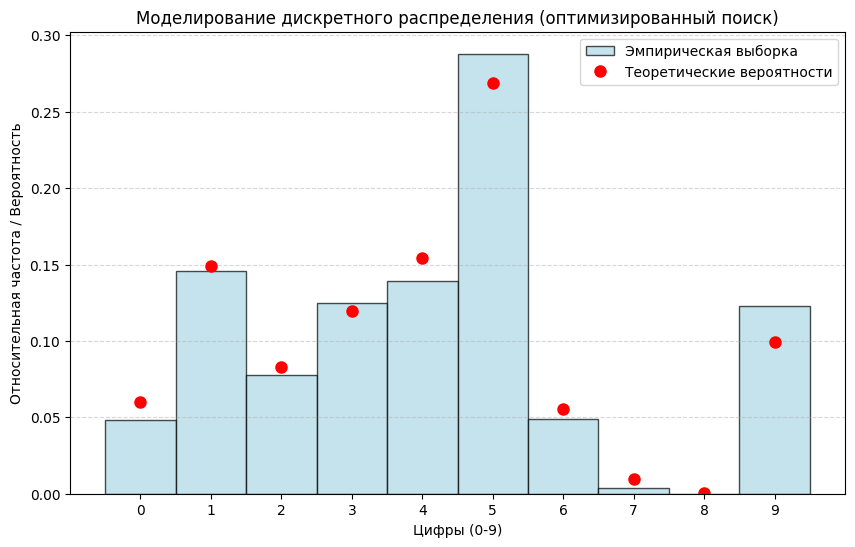

In [4]:
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

probs = weights / np.sum(weights)

sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
sorted_digits = digits[sorted_indices]

cdf = np.cumsum(sorted_probs)

n_samples = 1000
samples = np.zeros(n_samples, dtype=int)
random_vals = np.random.rand(n_samples)

for i in range(n_samples):
    u = random_vals[i]
    for j, cum_prob in enumerate(cdf):
        if u <= cum_prob:
            samples[i] = sorted_digits[j]
            break

plt.figure(figsize=(10, 6))

bins = np.arange(-0.5, 10.5, 1)

plt.hist(samples, bins=bins, density=True, alpha=0.7, edgecolor='black', color='lightblue', label='Эмпирическая выборка')

plt.plot(digits, probs, 'ro', markersize=8, label='Теоретические вероятности')

plt.xticks(digits)
plt.xlabel('Цифры (0-9)')
plt.ylabel('Относительная частота / Вероятность')
plt.title('Моделирование дискретного распределения (оптимизированный поиск)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4115/1766815369.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_vals, pdf_vals, 'r-', lw=2.5, label=f'Теоретическая плотность $\lambda={lmbda}$')
/tmp/ipykernel_4115/1766815369.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Симуляция Exp($\lambda$) методом обратного преобразования')


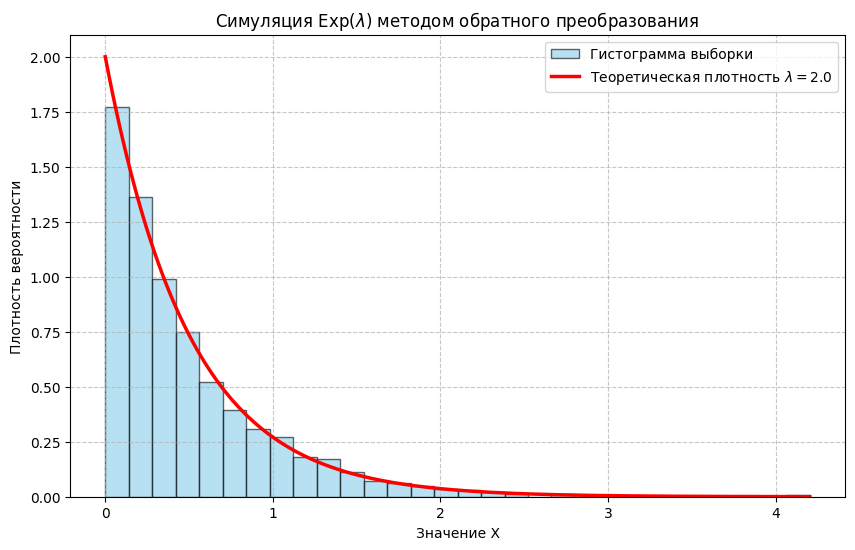

In [5]:
import numpy as np
import matplotlib.pyplot as plt

lmbda = 2.0
n = 1000

U = np.random.uniform(0, 1, n)

X = -np.log(1 - U) / lmbda

plt.figure(figsize=(10, 6))

plt.hist(X, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Гистограмма выборки')

x_vals = np.linspace(0, max(X), 200)
pdf_vals = lmbda * np.exp(-lmbda * x_vals)
plt.plot(x_vals, pdf_vals, 'r-', lw=2.5, label=f'Теоретическая плотность $\lambda={lmbda}$')

plt.title('Симуляция Exp($\lambda$) методом обратного преобразования')
plt.xlabel('Значение X')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

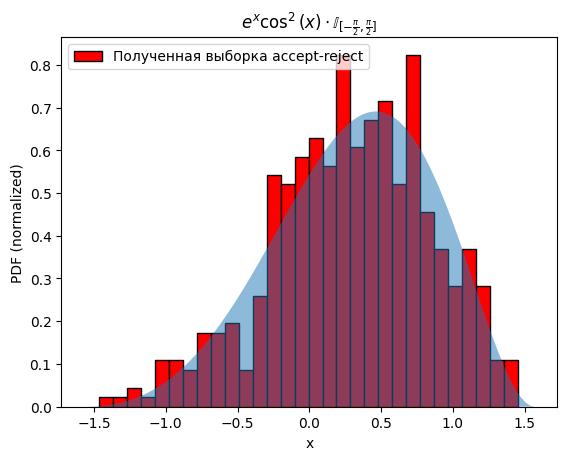

In [6]:


n = 1000
x = np.random.uniform(-np.pi/2, np.pi/2, n)
M = 1.271
y = np.random.uniform(0, M, n)
samples = x[y <= np.exp(x) * np.cos(x) ** 2]

fig = plt.figure()
plt.hist(samples, density = True, bins = 30, label = 'Полученная выборка accept-reject', color = 'red', edgecolor = 'black')
x_range = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x_range) * np.cos(x_range) ** 2
area = np.trapezoid(density, x_range)
plt.fill_between(x_range, 0, density / area, alpha = 0.5)
plt.ylabel('PDF (normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')
plt.legend()
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

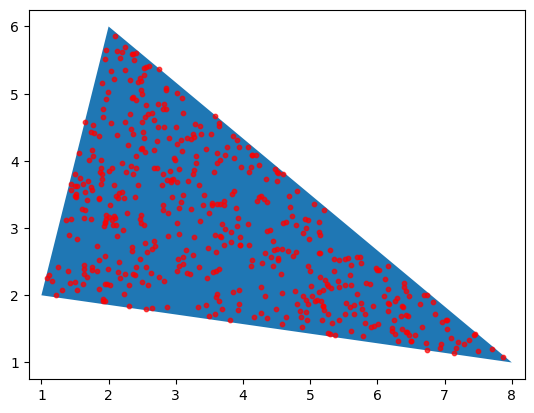

In [7]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')

n = 500
u1 = np.random.uniform(0, 1, n)
u2 = np.random.uniform(0, 1, n)
mask = (u1 + u2 > 1)
u1[mask], u2[mask] = 1 - u1[mask], 1 - u2[mask]

x = 1 + u1 + u2 * 7
y = 2 + u1 * 4 - u2

plt.scatter(x, y, c = 'r', s = 10, alpha = 0.7)
plt.show()



### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

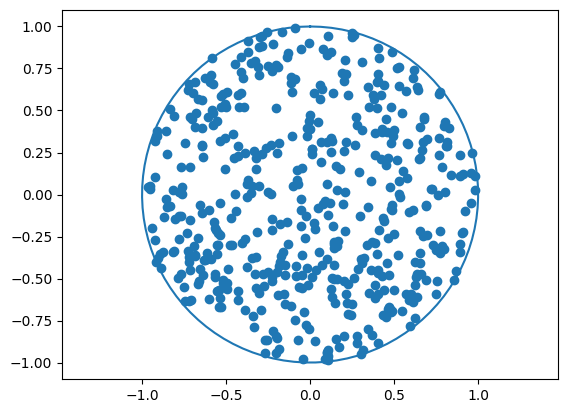

In [8]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')

n = 500
tetta = np.random.uniform(0, 2 * np.pi, n)
R  = np.sqrt(np.random.uniform(0, 1, n))
x = R * np.cos(tetta)
y = R * np.sin(tetta)

plt.scatter(x, y)

plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [9]:
import seaborn as sns

Выборочное среднее:
 [3.77276993 6.77707174]
Выборочная ковариация:
 [[19.92379973 -3.6520406 ]
 [-3.6520406  36.48567016]]


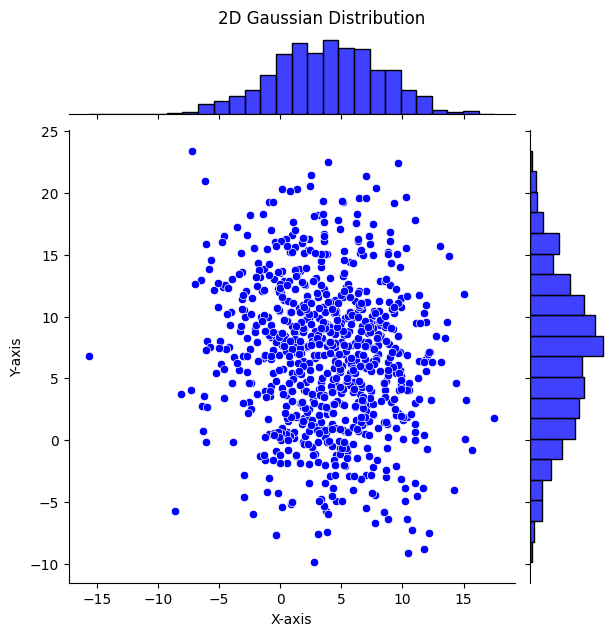

In [27]:
n = 1000

u1 = np.random.uniform(-1, 1, n)
u2 = np.random.uniform(-1, 1, n)
S = (u1**2 + u2**2)
mask = (S < 1) & (S > 0)
v1 = u1[mask]
v2 = u2[mask]
S_masked = S[mask]



r = np.sqrt(-2 * np.log(S_masked))
cosine = v1 / np.sqrt(S_masked)
sine = v2 / np.sqrt(S_masked)

x = r * cosine
y = r * sine

Z = np.vstack([x, y])
mu = np.array([[4], [7]])
sigma = np.array([[20, -4],
                 [-4, 40]])
L = np.linalg.cholesky(sigma)


Z_final = mu + L @ Z

x_res = Z_final[0, :]
y_res = Z_final[1, :]

print("Выборочное среднее:\n", np.mean(Z_final, axis=1))
print("Выборочная ковариация:\n", np.cov(Z_final))

joint_plot = sns.jointplot(x=x_res, y=y_res, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()